# AML s26 - KNN Regression

## Import Libraries

Import necessary libraries for data generation, modeling, evaluation, and visualization.

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Generate Synthetic Data

Create a 1D dataset based on a sine function with added Gaussian noise.

Dataset size: 80 samples
X range: [0.09, 4.94]
y range: [-1.43, 1.54]


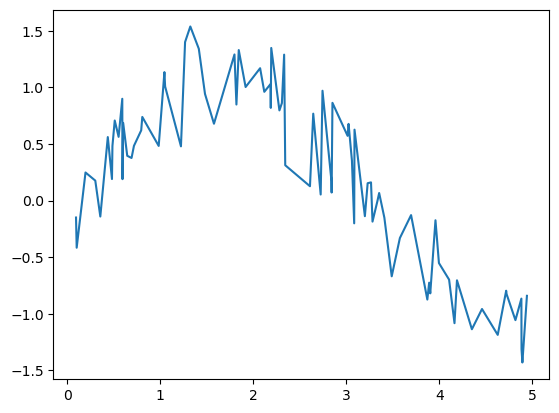

In [47]:
# Set random seed for reproducibility
rng = np.random.RandomState(0)

# Generate 80 random points between 0 and 5, sorted
X = np.sort(5 * rng.rand(80, 1), axis=0)

# Create target variable: sine function with added noise
y = np.sin(X).ravel()  # True sine function
y += 0.3 * rng.randn(X.shape[0])  # Add Gaussian noise

print(f"Dataset size: {X.shape[0]} samples")
print(f"X range: [{X.min():.2f}, {X.max():.2f}]")
print(f"y range: [{y.min():.2f}, {y.max():.2f}]")

plt.plot(X,y)
plt.show()

## Train-Test Split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 48 samples
Test set size: 32 samples


## Train KNN Regressor

Select K (n_neighbors)

In [49]:
reg = KNeighborsRegressor(n_neighbors=13)

reg.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Number of neighbors (k): {reg.n_neighbors}")

Model trained successfully!
Number of neighbors (k): 13


## Make Predictions on Test Set

In [50]:
y_pred_test = reg.predict(X_test)

print(f"Number of predictions made: {len(y_pred_test)}")

Number of predictions made: 32


## Evaluate Model Performance


In [51]:
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("Test Set Evaluation Metrics")
print("-" * 50)
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"R² Score:                       {r2:.4f}")
print("-" * 50)

Test Set Evaluation Metrics
--------------------------------------------------
Mean Squared Error (MSE):       0.1068
Root Mean Squared Error (RMSE): 0.3267
Mean Absolute Error (MAE):      0.2656
R² Score:                       0.7912
--------------------------------------------------


## Visualize the Learned Function


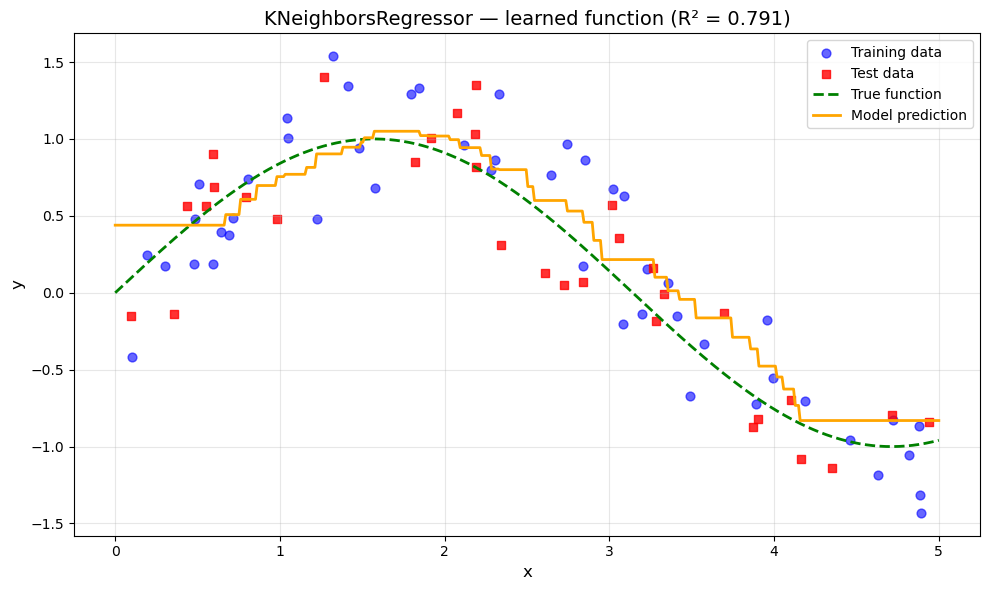

In [52]:
# Create fine-grained x values for smooth plotting
X_plot = np.linspace(0, 5, 500).reshape(-1, 1)

# Get model predictions for plotting
y_pred_plot = reg.predict(X_plot)

# Calculate true sine values for comparison
y_true_plot = np.sin(X_plot).ravel()

# Create the plot
plt.figure(1, figsize=(10, 6))

# Plot training data
plt.scatter(X_train, y_train, s=40, alpha=0.6, label="Training data", color='blue')

# Plot test data with different marker
plt.scatter(X_test, y_test, s=40, alpha=0.8, label="Test data", color='red', marker='s')

# Plot true function
plt.plot(X_plot, y_true_plot, "--", linewidth=2, label="True function", color='green')

# Plot model predictions
plt.plot(X_plot, y_pred_plot, linewidth=2, label="Model prediction", color='orange')

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title(f"KNeighborsRegressor — learned function (R² = {r2:.3f})", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()